# 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

# 2: Load Dataset

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# 3: Data Overview

In [45]:
df.shape

(1025, 14)

In [47]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


# 4: Univariate Analysis (Histograms)

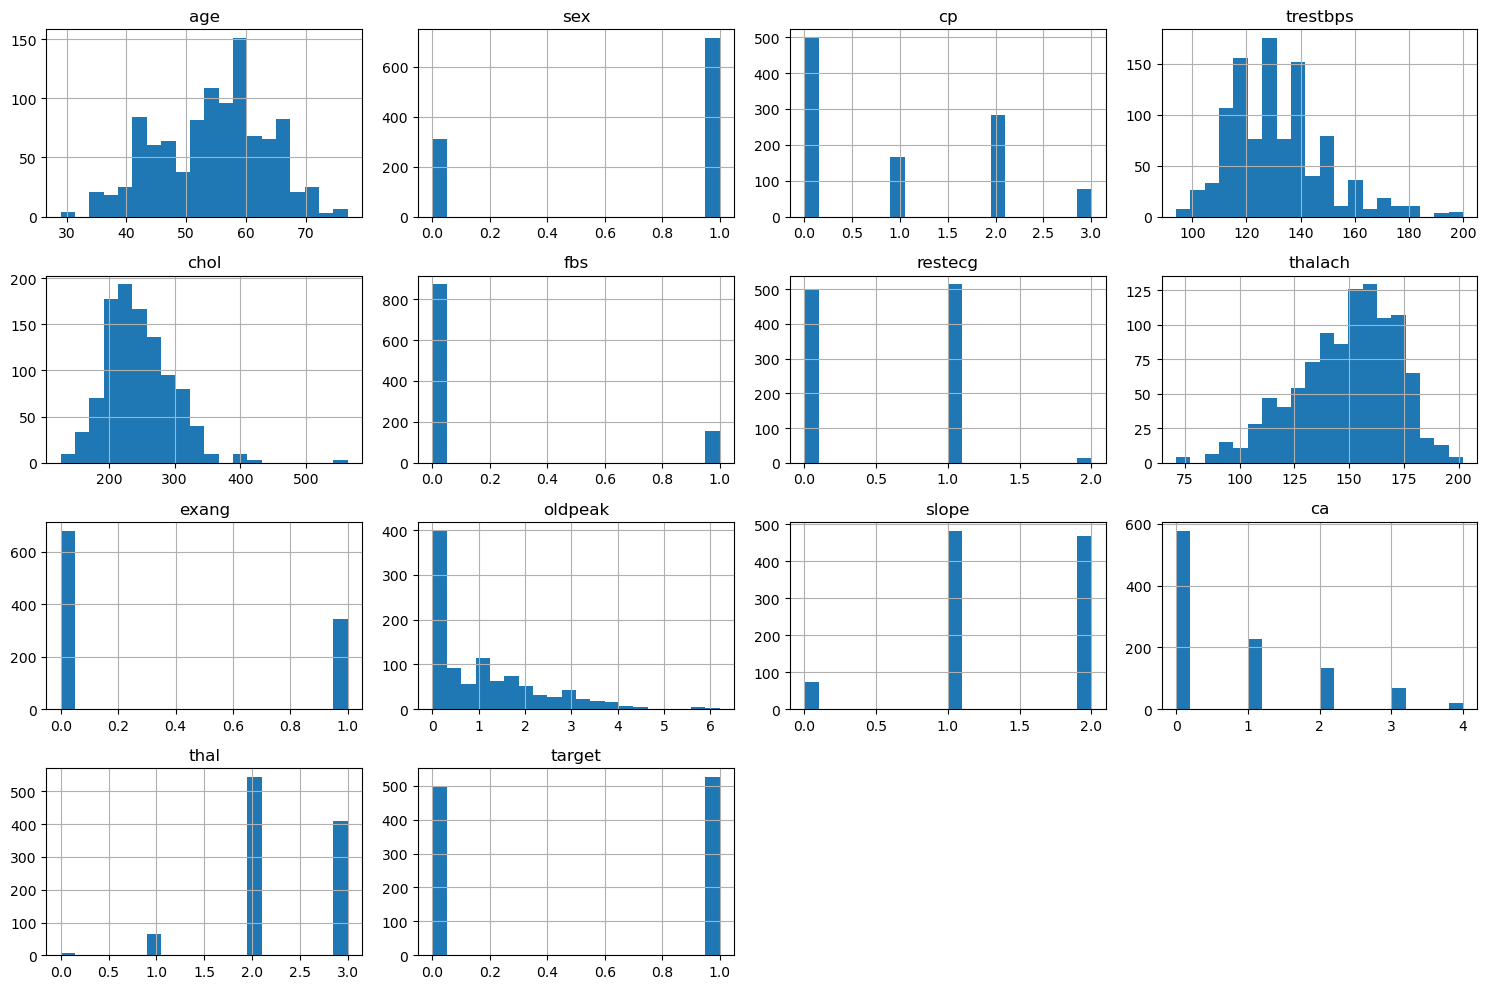

In [3]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

# 5: Bivariate Analysis (Correlation Heatmap)

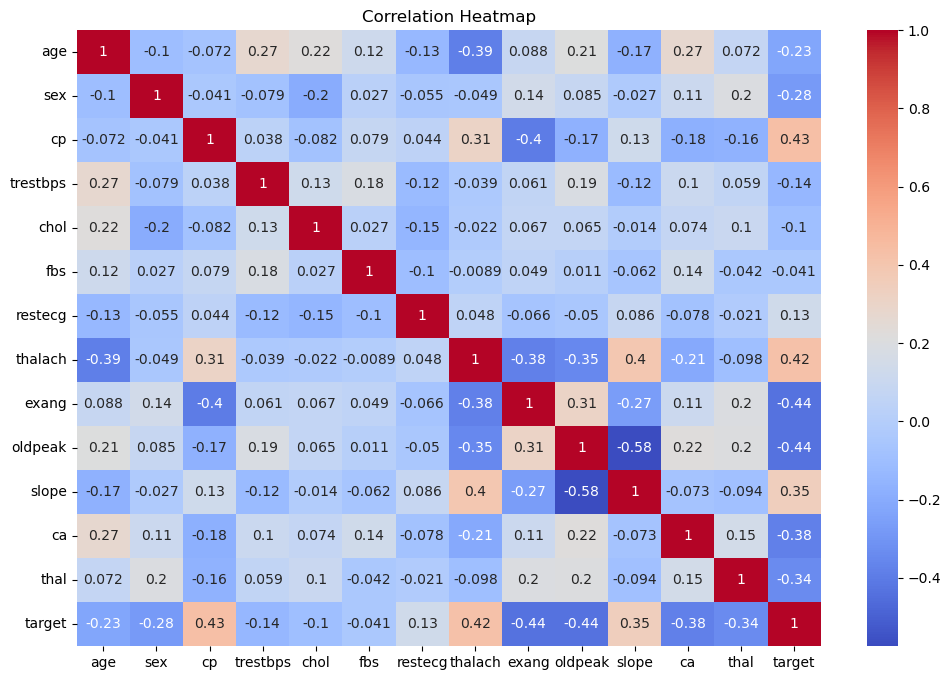

In [4]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# 6: Outlier Detection (Boxplots)

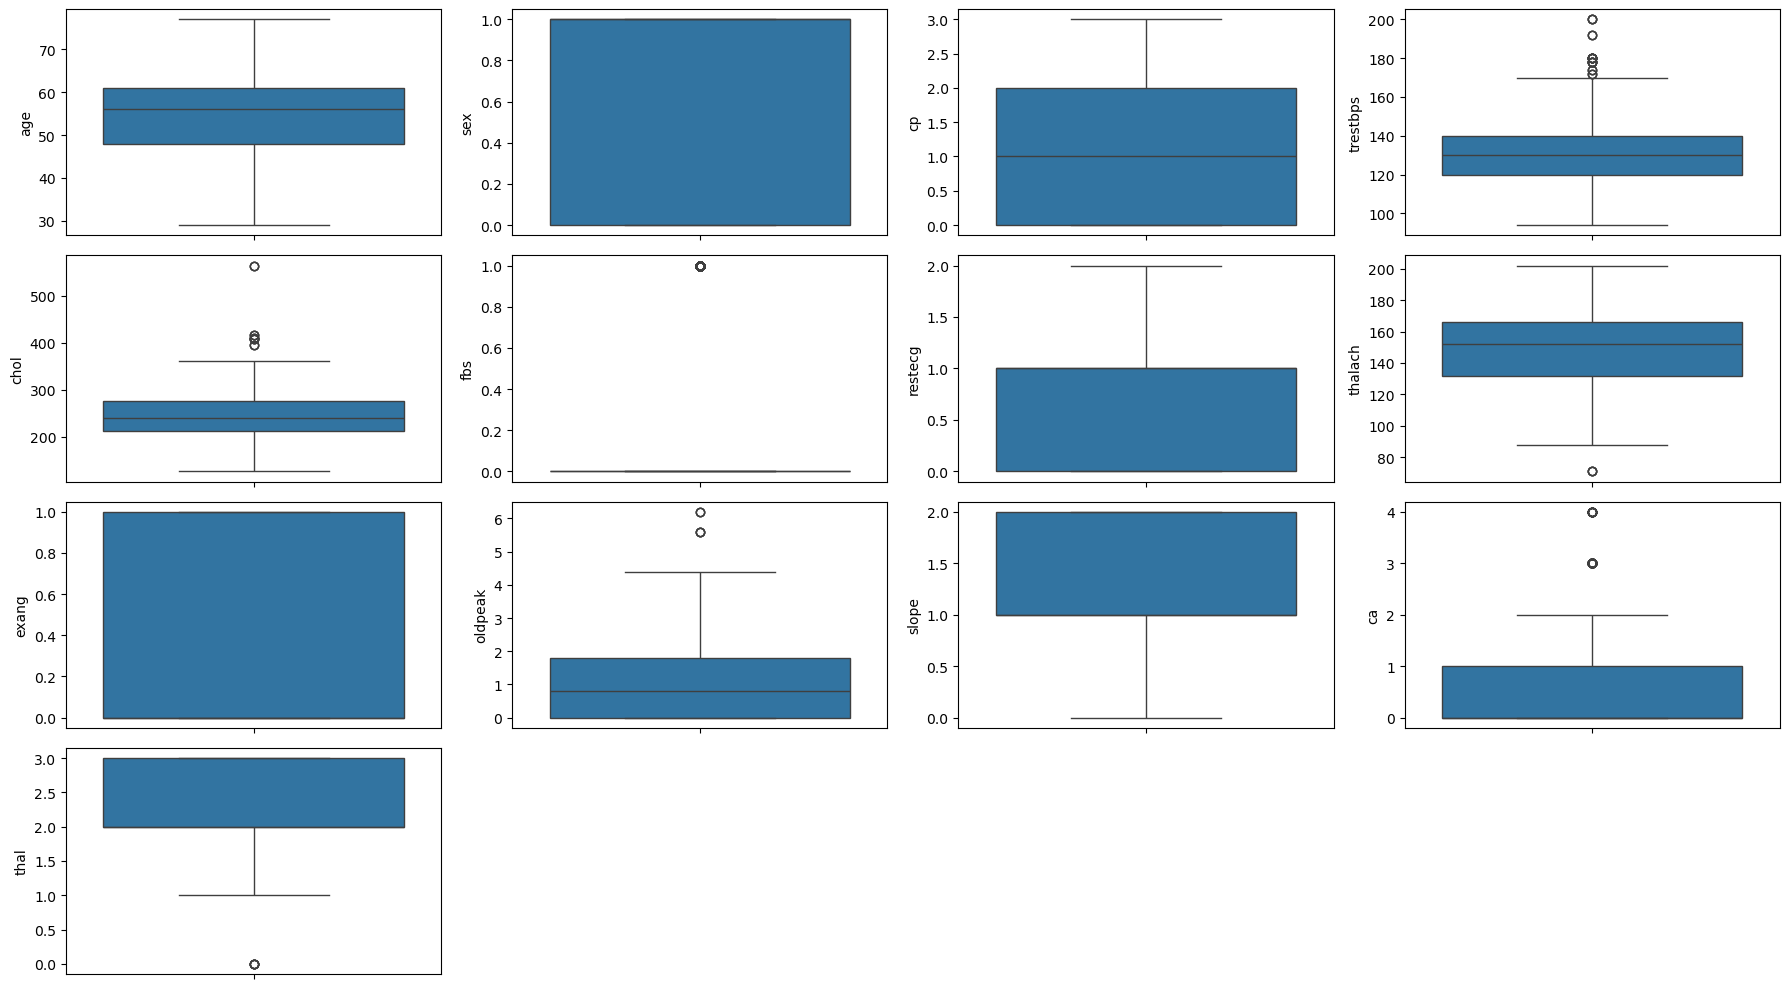

In [5]:
plt.figure(figsize=(18,10))

for i,col in enumerate(df.columns[:-1],1):
    plt.subplot(4,4,i)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

# 7: Split Data into Train-Test

In [6]:
X = df.drop('target', axis=1)
y = df['target']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 8: Train Decision Tree

In [8]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

# 9: Evaluate Decision Tree

In [12]:
dt.score(X_test,y_test)

0.9853658536585366

In [14]:
dt.score(X_train,y_train)

1.0

# 10: Train KNeighborsClassifier

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

KNeighborsClassifier()

# 11: Evaluate KNN

In [18]:
knn.score(X_test,y_test)

0.7317073170731707

In [19]:
knn.score(X_train,y_train)

0.9231707317073171

# 12: Train GaussianNB

In [20]:
gnb = GaussianNB()

gnb.fit(X_train,y_train)

GaussianNB()

# 13: Evaluate GaussianNB

In [22]:
gnb.score(X_test,y_test)

0.8

In [24]:
gnb.score(X_train,y_train)

0.8390243902439024

# 14: Decision Tree CV

In [25]:
cv_dt = cross_val_score(
    dt,
    X,
    y,
    cv=10,
    scoring='accuracy'
)

print("CV Scores :",cv_dt)
print("Mean Accuracy :",cv_dt.mean())

CV Scores : [1.         1.         1.         0.97087379 1.         1.
 1.         1.         1.         1.        ]
Mean Accuracy : 0.9970873786407767


# 15: KNN CV

In [26]:
cv_knn = cross_val_score(
    knn,
    X,
    y,
    cv=10,
    scoring='accuracy'
)

print("CV Scores :",cv_knn)
print("Mean Accuracy :",cv_knn.mean())

CV Scores : [0.76699029 0.78640777 0.74757282 0.77669903 0.77669903 0.76470588
 0.70588235 0.76470588 0.78431373 0.7254902 ]
Mean Accuracy : 0.7599466971254522


# 16: GaussianNB CV

In [27]:
cv_gnb = cross_val_score(
    gnb,
    X,
    y,
    cv=10,
    scoring='accuracy'
)

print("CV Scores :",cv_gnb)
print("Mean Accuracy :",cv_gnb.mean())

CV Scores : [0.85436893 0.88349515 0.87378641 0.76699029 0.84466019 0.88235294
 0.76470588 0.78431373 0.75490196 0.80392157]
Mean Accuracy : 0.821349704930516


# 17: Train Bagging Classifier

In [28]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bag.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=42)

In [29]:
y_pred_bag = bag.predict(X_test)

print("Accuracy :",accuracy_score(y_test,y_pred_bag))

Accuracy : 0.9853658536585366


# 19: Train Random Forest

In [30]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

# 20:Evaluate Random Forest

In [32]:
y_pred_rf = rf.predict(X_test)

print("Accuracy :",accuracy_score(y_test,y_pred_rf))

Accuracy : 0.9853658536585366


# 21:Train AdaBoost

In [33]:
ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [34]:
y_pred_ada = ada.predict(X_test)

print("Accuracy :",accuracy_score(y_test,y_pred_ada))

Accuracy : 0.8341463414634146


# 23: ROC for Decision Tree

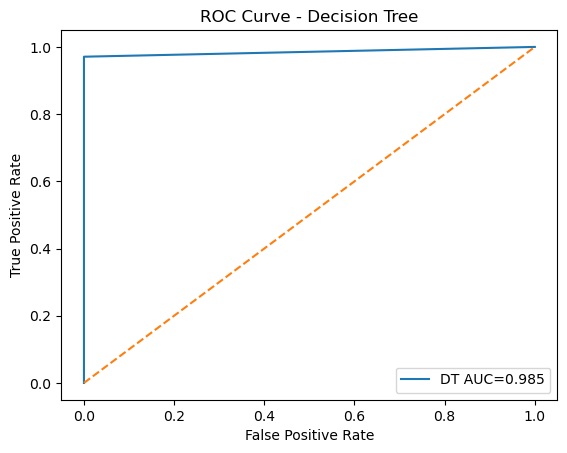

In [40]:
y_prob_dt = dt.predict_proba(X_test)[:,1]

fpr_dt,tpr_dt,_ = roc_curve(y_test,y_prob_dt)

auc_dt = roc_auc_score(y_test,y_prob_dt)

plt.plot(fpr_dt,tpr_dt,label=f'DT AUC={auc_dt:.3f}')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

# 24 :ROC for Random Forest

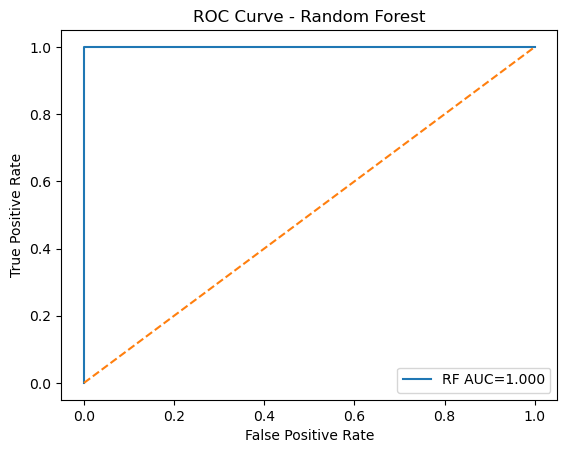

In [37]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr_rf,tpr_rf,_ = roc_curve(y_test,y_prob_rf)

auc_rf = roc_auc_score(y_test,y_prob_rf)

plt.plot(fpr_rf,tpr_rf,label=f'RF AUC={auc_rf:.3f}')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# 25: ROC for AdaBoost

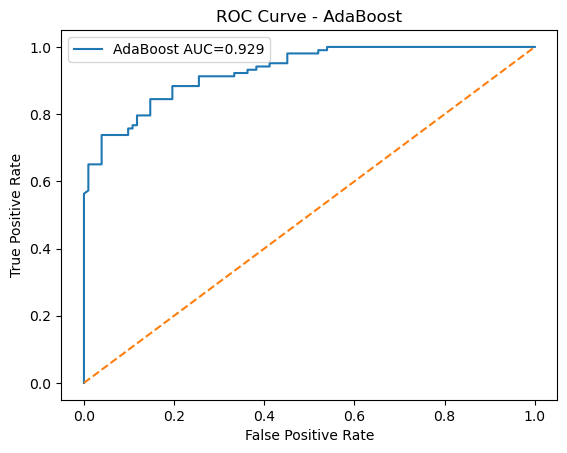

In [38]:
y_prob_ada = ada.predict_proba(X_test)[:,1]

fpr_ada,tpr_ada,_ = roc_curve(y_test,y_prob_ada)

auc_ada = roc_auc_score(y_test,y_prob_ada)

plt.plot(fpr_ada,tpr_ada,label=f'AdaBoost AUC={auc_ada:.3f}')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AdaBoost")
plt.legend()
plt.show()

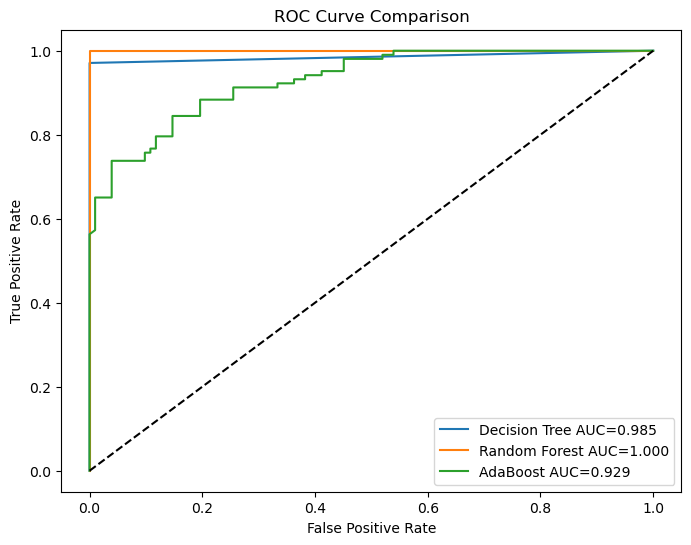

In [41]:
plt.figure(figsize=(8,6))

plt.plot(fpr_dt,tpr_dt,
         label=f'Decision Tree AUC={auc_dt:.3f}')

plt.plot(fpr_rf,tpr_rf,
         label=f'Random Forest AUC={auc_rf:.3f}')

plt.plot(fpr_ada,tpr_ada,
         label=f'AdaBoost AUC={auc_ada:.3f}')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()